## Imports & path

In [1]:
import gzip
import json
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
)

plt.style.use("seaborn-v0_8")

DATA_PATH = "renttherunway_final_data.json.gz"


## Parser + load DataFrame

In [2]:
def parse_rtr(path):
    """Parse line-delimited JSON objects from renttherunway_final_data.json.gz."""
    with gzip.open(path, "rt", encoding="utf-8") as g:
        for line in g:
            line = line.strip()
            if not line:
                continue
            yield json.loads(line)


records = list(parse_rtr(DATA_PATH))
df = pd.DataFrame(records)

print("Rows:", len(df))
df.head()


Rows: 192544


,fit,user_id,bust size,item_id,weight,rating,rented for,review_text,body type,review_summary,category,height,size,age,review_date
0,fit,420272,34d,2260466,137lbs,10,vacation,An adorable romper! Belt and zipper were a lit...,hourglass,So many compliments!,romper,"5' 8""",14,28,"April 20, 2016"
1,fit,273551,34b,153475,132lbs,10,other,I rented this dress for a photo shoot. The the...,straight & narrow,I felt so glamourous!!!,gown,"5' 6""",12,36,"June 18, 2013"
2,fit,360448,NaN,1063761,NaN,10,party,This hugged in all the right places! It was a ...,NaN,It was a great time to celebrate the (almost) ...,sheath,"5' 4""",4,116,"December 14, 2015"
3,fit,909926,34c,126335,135lbs,8,formal affair,I rented this for my company's black tie award...,pear,Dress arrived on time and in perfect condition.,dress,"5' 5""",8,34,"February 12, 2014"
4,fit,151944,34b,616682,145lbs,10,wedding,I have always been petite in my upper body and...,athletic,Was in love with this dress !!!,gown,"5' 9""",12,27,"September 26, 2016"


## Feature engineering: height, weight, bust, target

In [3]:
def parse_height_to_inches(x):
    """
    Convert height like "5' 8\"" to inches.
    """
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    m = re.match(r"(\d+)'[\s]*(\d+)", s)
    if m:
        feet = int(m.group(1))
        inches = int(m.group(2))
        return feet * 12 + inches
    try:
        return float(s)
    except ValueError:
        return np.nan


def parse_weight_to_lbs(x):
    """
    Convert weight like '137lbs' or '137' to float (lbs).
    """
    if pd.isna(x):
        return np.nan
    s = str(x).lower()
    m = re.match(r"(\d+\.?\d*)", s)
    if m:
        return float(m.group(1))
    return np.nan


# height / weight
df["height_inches"] = df["height"].apply(parse_height_to_inches)
df["weight_lbs"] = df["weight"].apply(parse_weight_to_lbs)

# bust size numeric part, e.g. '34d' -> 34
df["bust_numeric"] = pd.to_numeric(
    df["bust size"].str.extract(r"(\d+)", expand=False), errors="coerce"
)

# ensure numeric types for rating & age
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["age"] = pd.to_numeric(df["age"], errors="coerce")

# fill text nulls
df["review_text"] = df["review_text"].fillna("")

# keep only rows with fit label
df = df[df["fit"].notna()].copy()

# binary target: 1 = 'fit', 0 = others (small/large etc.)
df["fit_binary"] = (df["fit"].str.lower() == "fit").astype(int)

print("Fit label distribution:\n", df["fit"].value_counts())
print("\nBinary target distribution:\n", df["fit_binary"].value_counts(normalize=True))

df.head()


Fit label distribution:
 fit
fit      142058
small     25779
large     24707
Name: count, dtype: int64

Binary target distribution:
 fit_binary
1    0.737795
0    0.262205
Name: proportion, dtype: float64


,fit,user_id,bust size,item_id,weight,rating,rented for,review_text,body type,review_summary,category,height,size,age,review_date,height_inches,weight_lbs,bust_numeric,fit_binary
0,fit,420272,34d,2260466,137lbs,10.0,vacation,An adorable romper! Belt and zipper were a lit...,hourglass,So many compliments!,romper,"5' 8""",14,28.0,"April 20, 2016",68.0,137.0,34.0,1
1,fit,273551,34b,153475,132lbs,10.0,other,I rented this dress for a photo shoot. The the...,straight & narrow,I felt so glamourous!!!,gown,"5' 6""",12,36.0,"June 18, 2013",66.0,132.0,34.0,1
2,fit,360448,NaN,1063761,NaN,10.0,party,This hugged in all the right places! It was a ...,NaN,It was a great time to celebrate the (almost) ...,sheath,"5' 4""",4,116.0,"December 14, 2015",64.0,NaN,NaN,1
3,fit,909926,34c,126335,135lbs,8.0,formal affair,I rented this for my company's black tie award...,pear,Dress arrived on time and in perfect condition.,dress,"5' 5""",8,34.0,"February 12, 2014",65.0,135.0,34.0,1
4,fit,151944,34b,616682,145lbs,10.0,wedding,I have always been petite in my upper body and...,athletic,Was in love with this dress !!!,gown,"5' 9""",12,27.0,"September 26, 2016",69.0,145.0,34.0,1


## Exploratory Data Analysis

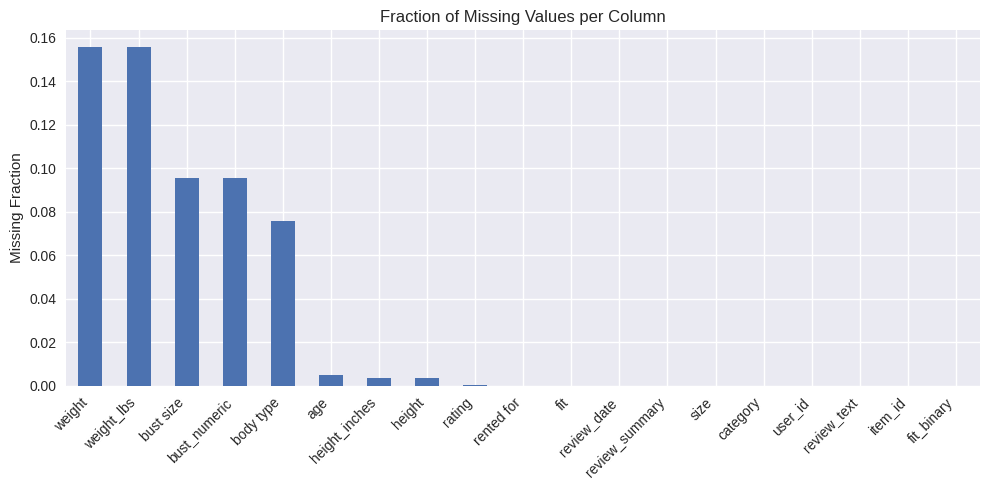

In [4]:
# 1 Missing Values Overview
plt.figure(figsize=(10, 5))
missing = df.isna().mean().sort_values(ascending=False)
missing.plot(kind="bar")
plt.title("Fraction of Missing Values per Column")
plt.ylabel("Missing Fraction")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


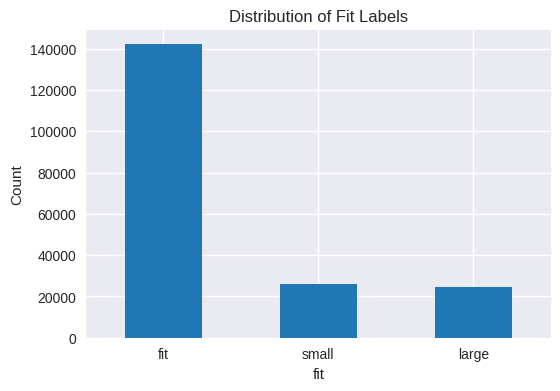

fit
fit      0.737795
small    0.133886
large    0.128319
Name: proportion, dtype: float64


In [5]:
# 2 Fit Label Distribution
plt.figure(figsize=(6, 4))
df["fit"].value_counts().plot(kind="bar", color=["#1f77b4"])
plt.title("Distribution of Fit Labels")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

print(df["fit"].value_counts(normalize=True))


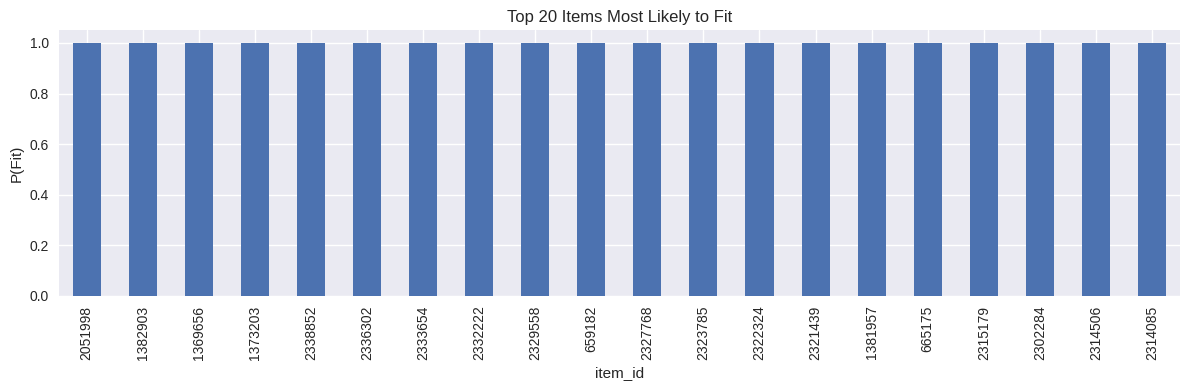

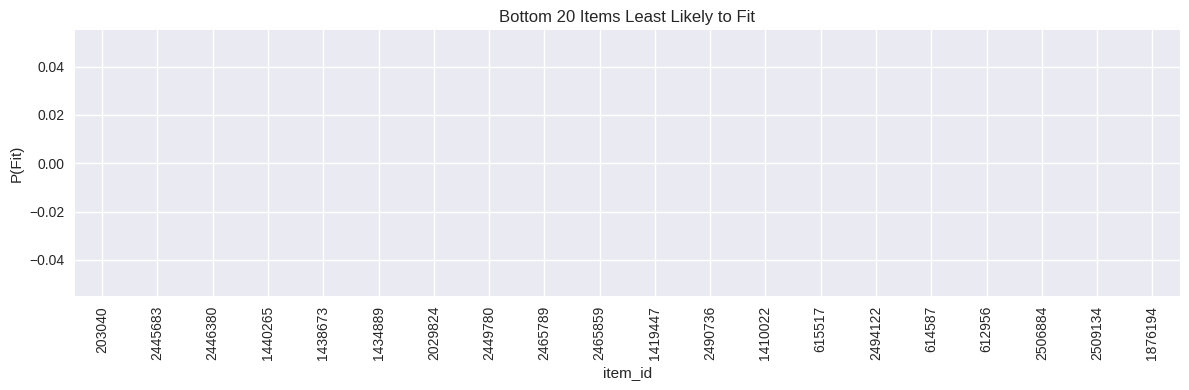

In [6]:
# 3 Item-Level Fit Signatures
item_fit = df.groupby("item_id")["fit_binary"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 4))
item_fit.head(20).plot(kind="bar")
plt.title("Top 20 Items Most Likely to Fit")
plt.ylabel("P(Fit)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
item_fit.tail(20).plot(kind="bar", color="orange")
plt.title("Bottom 20 Items Least Likely to Fit")
plt.ylabel("P(Fit)")
plt.tight_layout()
plt.show()


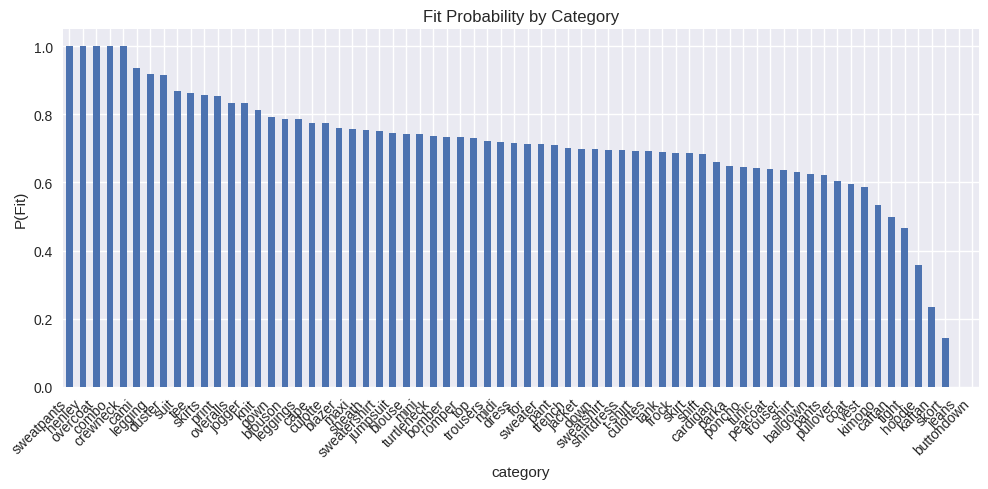

In [7]:
# 4 Category-Level Fit Trends
cat_fit = df.groupby("category")["fit_binary"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
cat_fit.plot(kind="bar")
plt.title("Fit Probability by Category")
plt.ylabel("P(Fit)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


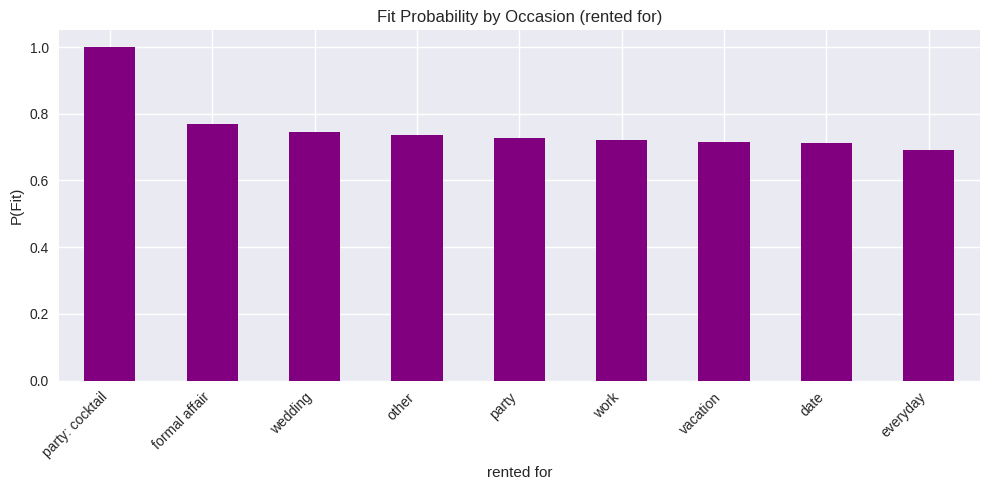

In [8]:
# 5 Occasion (“rented for”) Fit Patterns
occasion_fit = (
    df.groupby("rented for")["fit_binary"].mean().sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
occasion_fit.plot(kind="bar", color="purple")
plt.title("Fit Probability by Occasion (rented for)")
plt.ylabel("P(Fit)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


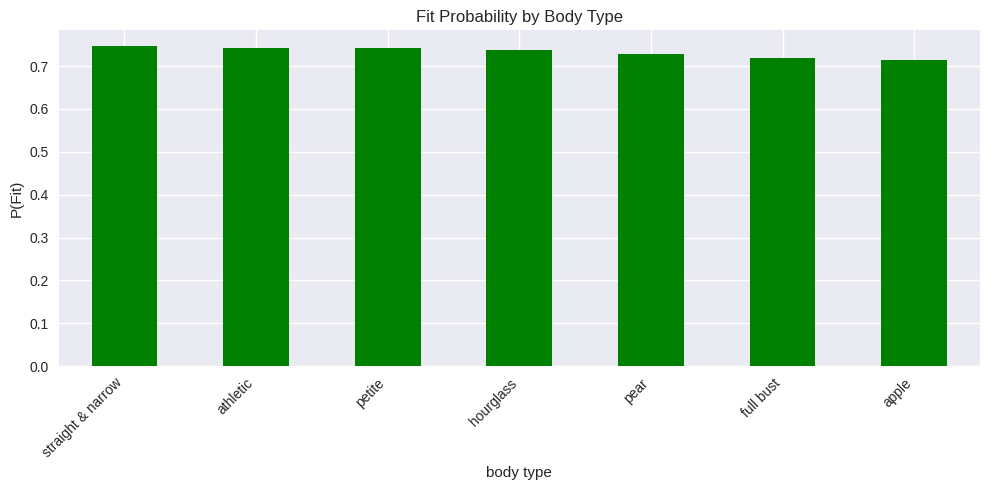

In [9]:
# 6 Body Type Effects
body_fit = df.groupby("body type")["fit_binary"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
body_fit.plot(kind="bar", color="green")
plt.title("Fit Probability by Body Type")
plt.ylabel("P(Fit)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


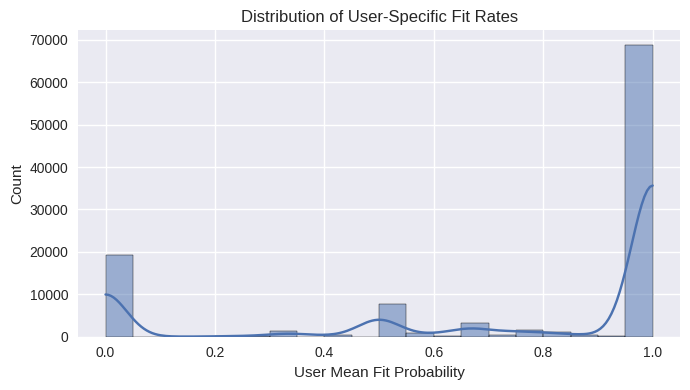

In [10]:
# 7 User-Level Fit Tendencies
user_fit_rates = df.groupby("user_id")["fit_binary"].mean()

plt.figure(figsize=(7, 4))
sns.histplot(user_fit_rates, bins=20, kde=True)
plt.title("Distribution of User-Specific Fit Rates")
plt.xlabel("User Mean Fit Probability")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


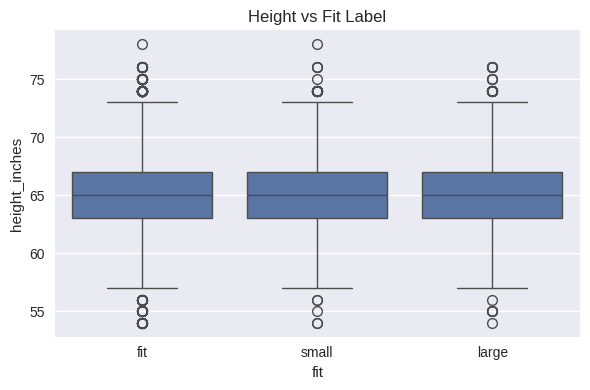

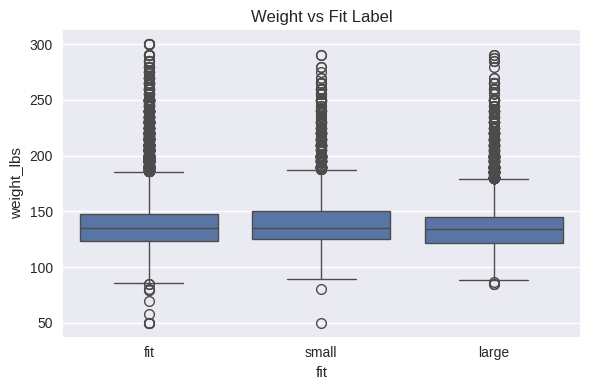

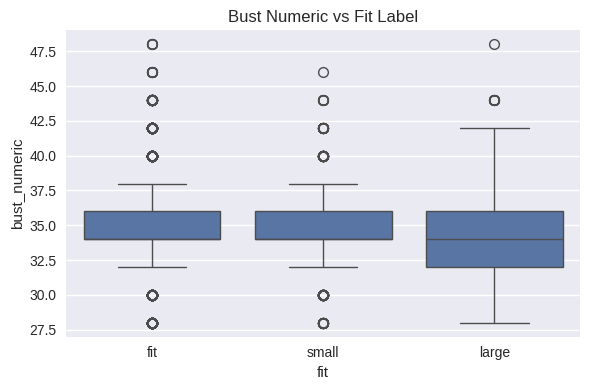

In [11]:
# 8 Measurement Correlations
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="fit", y="height_inches")
plt.title("Height vs Fit Label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="fit", y="weight_lbs")
plt.title("Weight vs Fit Label")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="fit", y="bust_numeric")
plt.title("Bust Numeric vs Fit Label")
plt.tight_layout()
plt.show()


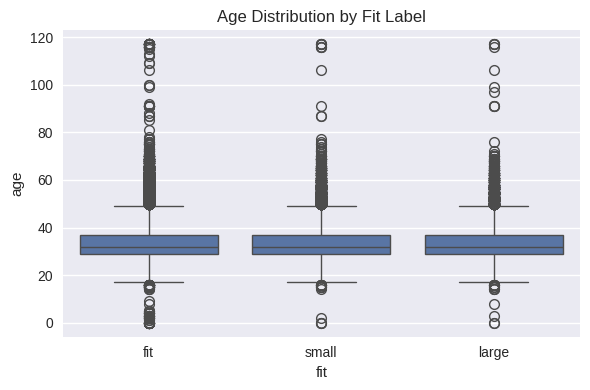

In [12]:
# 9 Age Patterns
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="fit", y="age")
plt.title("Age Distribution by Fit Label")
plt.tight_layout()
plt.show()


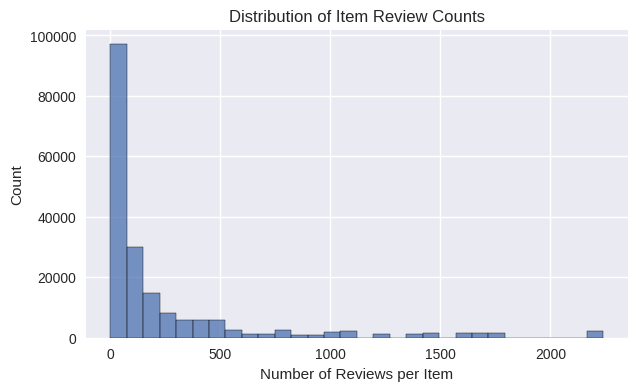

/tmp/ipykernel_50101/1192391659.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_fit = df.groupby("item_bucket")["fit_binary"].mean()


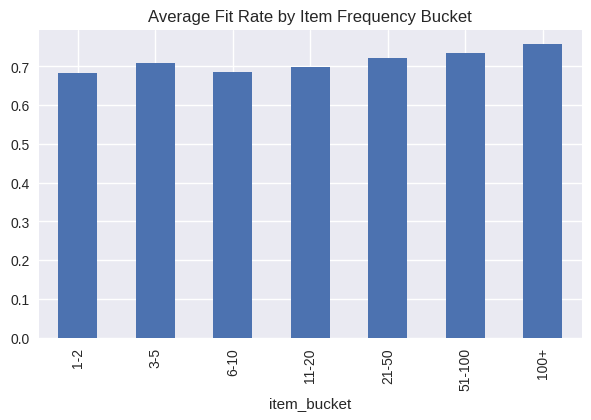

In [13]:
# 10 Cold-Start Item Analysis
item_counts = df["item_id"].value_counts()
df["item_freq"] = df["item_id"].map(item_counts)

plt.figure(figsize=(7, 4))
sns.histplot(df["item_freq"], bins=30)
plt.title("Distribution of Item Review Counts")
plt.xlabel("Number of Reviews per Item")
plt.show()

# bucket items
df["item_bucket"] = pd.cut(
    df["item_freq"],
    bins=[0, 2, 5, 10, 20, 50, 100, 1000],
    labels=["1-2", "3-5", "6-10", "11-20", "21-50", "51-100", "100+"],
)
bucket_fit = df.groupby("item_bucket")["fit_binary"].mean()

plt.figure(figsize=(7, 4))
bucket_fit.plot(kind="bar")
plt.title("Average Fit Rate by Item Frequency Bucket")
plt.show()


In [14]:
# 11 Top words for FIT vs NOT-FIT
from sklearn.feature_extraction.text import CountVectorizer

print("=== Top words for FIT vs NOT-FIT ===")

vec = CountVectorizer(stop_words="english", min_df=20)
X_text = vec.fit_transform(df["review_text"])
vocab = np.array(vec.get_feature_names_out())

# CORRECT FIT MASK
fit_mask = (df["fit_binary"] == 1).values

# FIT word counts
fit_counts = X_text[fit_mask].sum(axis=0).A1

# NOT-FIT word counts (use the opposite mask)
notfit_mask = ~fit_mask
notfit_counts = X_text[notfit_mask].sum(axis=0).A1

# Top indices
top_fit_idx = np.argsort(fit_counts)[-20:]
top_notfit_idx = np.argsort(notfit_counts)[-20:]

print("\nTop words in FIT reviews:\n", vocab[top_fit_idx])
print("\nTop words in NOT-FIT reviews:\n", vocab[top_notfit_idx])


=== Top words for FIT vs NOT-FIT ===

Top words in FIT reviews:
 ['didn' 'bit' 'got' 'night' 'long' 'length' 'bra' 'just' 'like' 'loved'
 'compliments' 'comfortable' 'little' 'perfect' 'wear' 'great' 'wore'
 'size' 'fit' 'dress']

Top words in NOT-FIT reviews:
 ['didn' 'really' 'just' 'large' 'like' 'tight' 'definitely' 'compliments'
 'loved' 'bit' 'comfortable' 'perfect' 'great' 'small' 'wore' 'little'
 'wear' 'fit' 'size' 'dress']


## Train/Val/Test split by user

In [15]:
# require user_id and item_id
df = df[df["user_id"].notna() & df["item_id"].notna()].copy()

print("Unique users:", df["user_id"].nunique())
print("Unique items:", df["item_id"].nunique())

all_users = df["user_id"].unique()
train_users, temp_users = train_test_split(all_users, test_size=0.3, random_state=42)
val_users, test_users = train_test_split(
    temp_users, test_size=2 / 3, random_state=42
)  # ~0.1 val, 0.2 test


def split_by_users(df, train_u, val_u, test_u):
    train_df = df[df["user_id"].isin(train_u)].copy()
    val_df = df[df["user_id"].isin(val_u)].copy()
    test_df = df[df["user_id"].isin(test_u)].copy()
    return train_df, val_df, test_df


train_df, val_df, test_df = split_by_users(df, train_users, val_users, test_users)

for name, part in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"{name}: {len(part)} rows, {part['user_id'].nunique()} users")


Unique users: 105571
Unique items: 5850
Train: 135422 rows, 73899 users
Val: 19117 rows, 10557 users
Test: 38005 rows, 21115 users


## Define feature columns

In [16]:
# categorical features
cat_cols = [
    "user_id",
    "item_id",
    "category",
    "rented for",
    "body type",
]

# numeric features
num_cols = [
    "bust_numeric",
    "size",
    "rating",
    "age",
    "height_inches",
    "weight_lbs",
]

text_col = "review_text"

print("Categorical:", cat_cols)
print("Numeric:", num_cols)
print("Text column:", text_col)


Categorical: ['user_id', 'item_id', 'category', 'rented for', 'body type']
Numeric: ['bust_numeric', 'size', 'rating', 'age', 'height_inches', 'weight_lbs']
Text column: review_text


## Hybrid preprocessing + model pipeline

In [17]:
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

text_transformer = Pipeline(
    steps=[("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2), min_df=5))]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
        ("txt", text_transformer, text_col),
    ]
)

clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs",
)

hybrid_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", clf),
    ]
)


## Train on train, evaluate on validation

In [18]:
feature_cols = cat_cols + num_cols + [text_col]

X_train = train_df[feature_cols]
y_train = train_df["fit_binary"]

X_val = val_df[feature_cols]
y_val = val_df["fit_binary"]

hybrid_model.fit(X_train, y_train)

val_probs = hybrid_model.predict_proba(X_val)[:, 1]
val_pred = (val_probs >= 0.5).astype(int)

print("Validation accuracy:", accuracy_score(y_val, val_pred))
print("Validation balanced accuracy:", balanced_accuracy_score(y_val, val_pred))
print("Validation macro F1:", f1_score(y_val, val_pred, average="macro"))
print("Validation AUC:", roc_auc_score(y_val, val_probs))

print("\nClassification report (val):\n")
print(classification_report(y_val, val_pred, target_names=["Not-Fit", "Fit"]))


Validation accuracy: 0.8094889365486216
Validation balanced accuracy: 0.770827415773576
Validation macro F1: 0.7618386363761374
Validation AUC: 0.8518397871642178

Classification report (val):

              precision    recall  f1-score   support

     Not-Fit       0.62      0.69      0.66      5022
         Fit       0.89      0.85      0.87     14095

    accuracy                           0.81     19117
   macro avg       0.75      0.77      0.76     19117
weighted avg       0.82      0.81      0.81     19117



## Final test evaluation

In [19]:
X_test = test_df[feature_cols]
y_test = test_df["fit_binary"]

test_probs = hybrid_model.predict_proba(X_test)[:, 1]
test_pred = (test_probs >= 0.5).astype(int)

print("Test accuracy:", accuracy_score(y_test, test_pred))
print("Test balanced accuracy:", balanced_accuracy_score(y_test, test_pred))
print("Test macro F1:", f1_score(y_test, test_pred, average="macro"))
print("Test AUC:", roc_auc_score(y_test, test_probs))

print("\nClassification report (test):\n")
print(classification_report(y_test, test_pred, target_names=["Not-Fit", "Fit"]))


Test accuracy: 0.8118405472964084
Test balanced accuracy: 0.774616861502083
Test macro F1: 0.765010323264192
Test AUC: 0.8553615756406452

Classification report (test):

              precision    recall  f1-score   support

     Not-Fit       0.63      0.70      0.66      9973
         Fit       0.89      0.85      0.87     28032

    accuracy                           0.81     38005
   macro avg       0.76      0.77      0.77     38005
weighted avg       0.82      0.81      0.81     38005



## Baseline models (for comparison)

In [20]:
# Majority-class baseline
print("=== Baseline: Majority (always predict 'Fit') ===")

y_test = test_df["fit_binary"].values
majority_pred = np.ones_like(y_test)  # always predict FIT

print("Accuracy:", accuracy_score(y_test, majority_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_test, majority_pred))
print("Macro F1:", f1_score(y_test, majority_pred, average="macro"))


=== Baseline: Majority (always predict 'Fit') ===
Accuracy: 0.7375871595842652
Balanced accuracy: 0.5
Macro F1: 0.4244893014522162


In [21]:
# Numeric-only baseline
print("\n=== Baseline: Numeric-only model ===")

num_only_cols = ["bust_numeric", "size", "rating", "age", "height_inches", "weight_lbs"]
num_only_cols = [c for c in num_only_cols if c in train_df.columns]

numeric_only_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            num_only_cols,
        )
    ]
)

num_only_model = Pipeline(
    steps=[
        ("preprocess", numeric_only_preprocess),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

# Fit
num_only_model.fit(train_df[num_only_cols], train_df["fit_binary"])

# Predict
test_probs_num = num_only_model.predict_proba(test_df[num_only_cols])[:, 1]
test_pred_num = (test_probs_num >= 0.5).astype(int)

print("Numeric-only Accuracy:", accuracy_score(y_test, test_pred_num))
print("Numeric-only Balanced accuracy:", balanced_accuracy_score(y_test, test_pred_num))
print("Numeric-only Macro F1:", f1_score(y_test, test_pred_num, average="macro"))
print("Numeric-only AUC:", roc_auc_score(y_test, test_probs_num))



=== Baseline: Numeric-only model ===
Numeric-only Accuracy: 0.6631495855808446
Numeric-only Balanced accuracy: 0.6222081673171673
Numeric-only Macro F1: 0.6056607958134888
Numeric-only AUC: 0.6427280508829318


In [22]:
# Text-only baseline
print("\n=== Baseline: Text-only model ===")

text_only = Pipeline(
    steps=[
        (
            "tfidf",
            TfidfVectorizer(
                max_features=15000,
                ngram_range=(1, 2),
                min_df=5,
                stop_words="english",
            ),
        ),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]
)

text_only.fit(train_df["review_text"], train_df["fit_binary"])

test_probs_text = text_only.predict_proba(test_df["review_text"])[:, 1]
test_pred_text = (test_probs_text >= 0.5).astype(int)

print("Text-only Accuracy:", accuracy_score(y_test, test_pred_text))
print("Text-only Balanced accuracy:", balanced_accuracy_score(y_test, test_pred_text))
print("Text-only Macro F1:", f1_score(y_test, test_pred_text, average="macro"))
print("Text-only AUC:", roc_auc_score(y_test, test_probs_text))



=== Baseline: Text-only model ===
Text-only Accuracy: 0.7810551243257466
Text-only Balanced accuracy: 0.7527142992128977
Text-only Macro F1: 0.7348852383167681
Text-only AUC: 0.8304559689872703


## Recommendation-style evaluation: Precision@K

In [23]:
print("\n=== Recommendation-style evaluation (Precision@K) ===")

test_df_rec = test_df.copy()
test_df_rec["proba_fit"] = test_probs  # from hybrid model


def precision_at_k(scores, labels, k):
    if len(scores) == 0:
        return np.nan
    order = np.argsort(-scores)
    topk_labels = labels[order][:k]
    if len(topk_labels) == 0:
        return np.nan
    return topk_labels.mean()


def mean_precision_at_k(df_user_item, k=5):
    vals = []
    for uid, group in df_user_item.groupby("user_id"):
        labels = group["fit_binary"].values
        if labels.sum() == 0:
            continue  # no positives for this user in test
        scores = group["proba_fit"].values
        vals.append(precision_at_k(scores, labels, k))
    return np.nanmean(vals) if len(vals) > 0 else np.nan


for k in [1, 3, 5, 10]:
    mpk = mean_precision_at_k(test_df_rec, k=k)
    print(f"Mean Precision@{k}: {mpk:.3f}")



=== Recommendation-style evaluation (Precision@K) ===
Mean Precision@1: 0.979
Mean Precision@3: 0.929
Mean Precision@5: 0.920
Mean Precision@10: 0.915


## Example recommendations for one user

In [24]:
all_items = df["item_id"].unique()


def recommend_for_user(user_id, k=5, n_samples=500):
    user_hist = df[df["user_id"] == user_id]["item_id"].unique()
    candidate_items = np.setdiff1d(all_items, user_hist)
    sample_items = np.random.choice(
        candidate_items, size=min(n_samples, len(candidate_items)), replace=False
    )

    cand = pd.DataFrame({"user_id": user_id, "item_id": sample_items})

    # attach item metadata
    item_meta = (
        df[["item_id", "category", "size", "review_text"]]
        .groupby("item_id")
        .agg(lambda x: x.iloc[0])
    )
    cand = cand.join(item_meta, on="item_id")

    # attach user metadata from first record
    user_row = df[df["user_id"] == user_id].iloc[0]
    for col in [
        "bust_numeric",
        "height_inches",
        "weight_lbs",
        "age",
        "rating",
        "rented for",
        "body type",
    ]:
        if col in df.columns:
            cand[col] = user_row[col]

    cand["review_text"] = cand["review_text"].fillna("")
    probs = hybrid_model.predict_proba(cand[feature_cols])[:, 1]
    cand["FitScore"] = probs

    return cand.sort_values("FitScore", ascending=False).head(k)


example_user = df["user_id"].sample(1).iloc[0]
recommend_for_user(example_user, k=5)


,user_id,item_id,category,size,review_text,bust_numeric,height_inches,weight_lbs,age,rating,rented for,body type,FitScore
429,414841,1911384,dress,8,Comfortable. True to size.,34.0,62.0,125.0,28.0,10.0,wedding,athletic,0.999988
170,414841,2520466,romper,8,Fit true to size!,34.0,62.0,125.0,28.0,10.0,wedding,athletic,0.999981
327,414841,2021539,top,4,fits true to size and is comfortable,34.0,62.0,125.0,28.0,10.0,wedding,athletic,0.999582
52,414841,907548,dress,8,I felt the dress fit very true to size. I lov...,34.0,62.0,125.0,28.0,10.0,wedding,athletic,0.999072
10,414841,2473413,top,4,Fits true to size. Great everyday top.,34.0,62.0,125.0,28.0,10.0,wedding,athletic,0.996672
